### Chain Using LangGraph
In this section we will see how we can build a simple chain using LangGrap that uses 4 important concepts

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes

In [112]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

### How to use chat messages as our graph state

#### Messages

We can use messages which can be used to capture different roles within a conversation. LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage. These represent a message from the user, from chat model, for the chat model to instruct behavior, and from tool call.

Every message have these important components.

- content - content of message
- name - specify the name of auditor
- response_metadata - optionally, a dict of metadata (eg- often populated by model provider for AIMessages)



In [113]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

messages= [ AIMessage(content=f"Please tell me how can I help", name="LLMModel") ]
messages.append(HumanMessage(content=f"I want to learn coding", name="Deepak"))
messages.append(AIMessage(content=f"Sure, I can help you with that. What programming language are you interested in?", name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn Python Programming Language", name="Deepak"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Deepak

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Sure, I can help you with that. What programming language are you interested in?
================================ Human Message =================================
Name: Deepak

I want to learn Python Programming Language


Chat model

In [114]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")
response=llm.invoke(messages)

In [115]:
response.pretty_print()

================================== Ai Message ==================================

Python is a great language to learn, and it's widely used in many fields, such as web development, data analysis, machine learning, and more. Here's a step-by-step guide to help you get started:

**Why Python?**

* Easy to learn and understand
* High-level language, meaning it's closer to human language
* Large community and plenty of resources
* Versatile and can be used for web development, data analysis, machine learning, and more

**Basic Requirements**

* A computer with a relatively recent operating system (Windows, macOS, or Linux)
* A text editor or IDE (Integrated Development Environment) like PyCharm, Visual Studio Code, or Sublime Text
* Python installed on your computer (you can download it from the official Python website)

**Learning Resources**

* **Official Python Documentation**: The official Python documentation is an excellent resource to learn Python. It's comprehensive, well-organized

In [116]:
response.response_metadata

{'token_usage': {'completion_tokens': 615,
  'prompt_tokens': 86,
  'total_tokens': 701,
  'completion_time': 1.388046626,
  'completion_tokens_details': None,
  'prompt_time': 0.007385993,
  'prompt_tokens_details': None,
  'queue_time': 0.163096207,
  'total_time': 1.395432619},
 'model_name': 'llama-3.3-70b-versatile',
 'system_fingerprint': 'fp_3272ea2d91',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

### Tools
tools can be integrated with the LLM modles to interact with internal systems. External systems can be API's, third party tools. 

whenever a query is asked the model can be choose to call the tool and this query is based on the natural language input and this will return an output that matches the tool's schema

In [117]:
def add(a:int, b:int)->int:
    """ Add a and b
    Args:
        a (int): first number
        b (int): second number
    Returns:
        int
    
    """
    return a+b

In [118]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x12a683e60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x12a85e2d0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [119]:
### binding tools with llm
llm_with_tools = llm.bind_tools([add])

tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is the sum of 2 and 3?", name="Deepak")])

In [120]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 3},
  'id': 'vksctys6g',
  'type': 'tool_call'}]

### using messages as state

In [121]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

# class State(TypedDict):
#     message: list[AnyMessage]



In [122]:
## Reducer

from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    


In [123]:
### Reducer with add messages

initial_message = [AIMessage(content=f"Please tell me how can I help", name="LLMModel")]
initial_message.append(HumanMessage(content=f"I want to learn coding", name="Deepak"))
initial_message 

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Deepak')]

In [124]:
ai_message = AIMessage(content=f"Sure, I can help you with that. What programming language are you interested in?", name="LLMModel")
ai_message


AIMessage(content='Sure, I can help you with that. What programming language are you interested in?', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [125]:
### Reducers add_messages is to append messages instead of overriding
add_messages(initial_message, ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='3979922a-ecf7-457e-83fd-d98ba5e4eb3b', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Deepak', id='dc1fc3d1-2da7-40e2-a9ee-521dbd2682bb'),
 AIMessage(content='Sure, I can help you with that. What programming language are you interested in?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='d0edaad5-0ecc-4d11-b08f-da7915b370be', tool_calls=[], invalid_tool_calls=[])]

In [126]:
## chatbot node functionality

def llm_tool(state: State): 
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

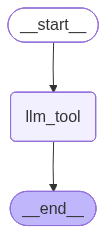

In [127]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder = StateGraph(State)

builder.add_node("llm_tool", llm_tool)

builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END) 

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [128]:
## invocation

messages = graph.invoke({"messages": "What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=add{"a": 2, "b": 2}</function>'}}

In [ ]:
tools = [add]

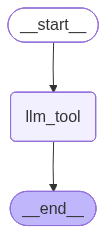

In [ ]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

tools = [add]

builder = StateGraph(State)

## Add nodes

builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

## Add Edge
builder.add_edge(START, "llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

graph_builder = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


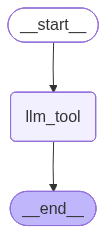

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))